In [60]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
import scipy.sparse as sp

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


In [61]:
H, W = 120, 40


# select samples to be used for normalization procedure
samples_idxs = np.arange(0,1000)
train_samples_path = Path(f"../../data/sxr_data/sxr_profiles_coarse")
train_samples_normalization = []
for sample_id_ in samples_idxs:
    path = os.path.join(train_samples_path, f"sxr_sample_{sample_id_}.npy")
    train_samples_normalization.append(np.load(path))
train_samples_normalization = torch.from_numpy(np.array(train_samples_normalization, dtype=np.float32)).to(device)

# load forward model
A_path = Path("forward_model/forward_model_sxr_full_geometry.npy")
A_sparse = np.load(A_path).astype(np.float32)
A_sparse /= A_sparse.max()  # normalize for better conditioning
print(A_sparse.min(), A_sparse.max(), A_sparse.shape)
A_tomo = torch.from_numpy(A_sparse).to(device)

# compute y_tomo distribution
y_tomo_train = train_samples_normalization.reshape(-1, H * W) @ A_tomo.T


0.0 1.0 (100, 4800)


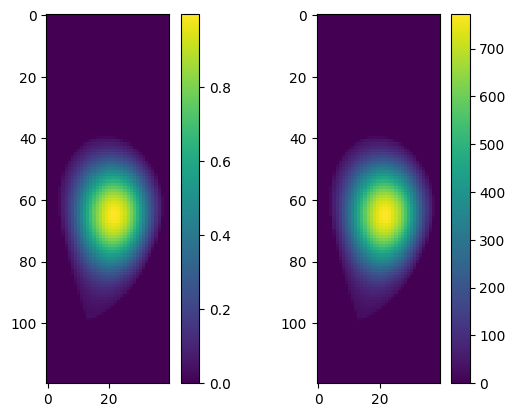

In [62]:
# load test samples
test_samples_path = Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy")
test_samples = torch.tensor(np.load(test_samples_path), dtype=torch.float32).to(device)

# compute y_tomo distribution for test samples
y_tomo_test = test_samples.reshape(-1, H * W) @ A_tomo.T

# deform distribution
test_samples_deformed = test_samples * torch.rand(test_samples.shape[0], device=device).reshape(-1,1,1) * 1000 

# compute y_tomo deformed distribution for test samples
y_tomo_test = test_samples_deformed.reshape(-1, H * W) @ A_tomo.T

plt.Figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_samples[16,:].cpu().numpy())
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(test_samples_deformed[16,:].cpu().numpy())
plt.colorbar()
plt.show()


In [75]:
def compute_closest_y(y, y_tomo_train):
    # Find the closest y_tomo_train to y
    y_norm = y / torch.norm(y, dim=1, keepdim=True)
    y_tomo_train_norm = y_tomo_train / torch.norm(y_tomo_train, dim=1, keepdim=True)
    idx = torch.argmin(torch.cdist(y_norm, y_tomo_train_norm))
    y_closest = y_tomo_train[idx]
    return y_closest

def compute_normalization_coefficient(y, y_tomo_train):
    y_closest = compute_closest_y(y, y_tomo_train).squeeze()
    coeff = torch.dot(y.squeeze(), y_closest) / torch.dot(y_closest, y_closest)
    return coeff.item()

In [76]:
closest = compute_closest_y(y_tomo_train[16,:].reshape(1, -1), y_tomo_train)
closest_test = compute_closest_y(y_tomo_test[16,:].reshape(1, -1), y_tomo_train)

# compute aplha
alpha = compute_normalization_coefficient(y_tomo_test[16,:].reshape(1, -1), y_tomo_train)
print("alpha:", alpha)

alpha: 861.6143188476562


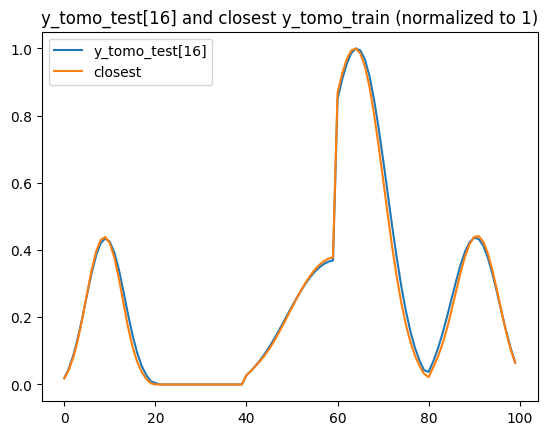

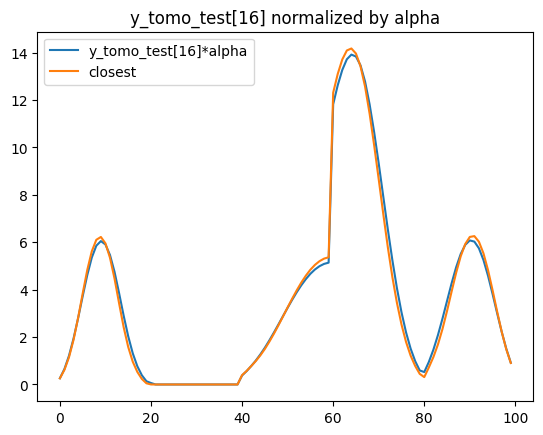

In [79]:
plt.plot(y_tomo_test[16,:].cpu().numpy()/y_tomo_test[16,:].cpu().numpy().max(), label="y_tomo_test[16]")
plt.plot(closest_test.cpu().numpy()/closest_test.cpu().numpy().max(), label="closest")
plt.legend()
plt.title("y_tomo_test[16] and closest y_tomo_train (normalized to 1)")
plt.show()  

plt.plot(y_tomo_test[16,:].cpu().numpy() / alpha, label="y_tomo_test[16]*alpha")
plt.plot(closest_test.cpu().numpy(), label="closest")
plt.legend()
plt.title("y_tomo_test[16] normalized by alpha")
plt.show()


In [ ]:
y_tomo_train[16,:].reshape(-1, 1).shape

torch.Size([100, 1])

In [ ]:
sample_idx = 9 #122, 2 , 9, 12